In [1]:
import ipywidgets as widgets
from IPython.display import display
import os

box_layout = widgets.Layout(
    display="flex",
    flex_flow="column",
    align_items="center",
    border="1px solid #E0E0E0",
    width="400px",
    padding="25px",
    border_radius="10px"
)

button_layout = widgets.Layout(width="100%", height="40px")

upload_layout = widgets.Layout(width="100%")

title = widgets.HTML(
    "<h3 style='margin-bottom:10px;'>Upload CSV Files 👇</h3>"
)

subtitle = widgets.HTML(
    "<p style='color:gray; margin-top:0;'>Select one or more CSV files to upload and save</p>"
)

train_uploader = widgets.FileUpload(
    accept='.csv',
    multiple=True,
    layout=upload_layout
)

save_button = widgets.Button(
    description='Save Files',
    button_style='primary',
    icon='save',
    layout=button_layout
)

status = widgets.HTML("<p style='color:gray;'>Waiting for upload...</p>")

output = widgets.Output()

def save_files(change=None):
    with output:
        output.clear_output()
        
        if train_uploader.value:
            saved_files = []
            for filename, file_info in train_uploader.value.items():
                with open(filename, "wb") as f:
                    f.write(file_info['content'])
                saved_files.append(filename)
            
            status.value = f"<p style='color:green;'>Saved {len(saved_files)} file(s) 👍</p>"
        else:
            status.value = "<p style='color:red;'>⚠️ No files uploaded yet</p>"

train_uploader.observe(save_files, names='value')

save_button.on_click(save_files)

card = widgets.VBox(
    [title, subtitle, train_uploader, save_button, status],
    layout=box_layout
)

display(card)
display(output)

Output()

In [2]:
import matplotlib.pyplot as plot
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('file.csv')

Text(0, 0.5, 'Package')

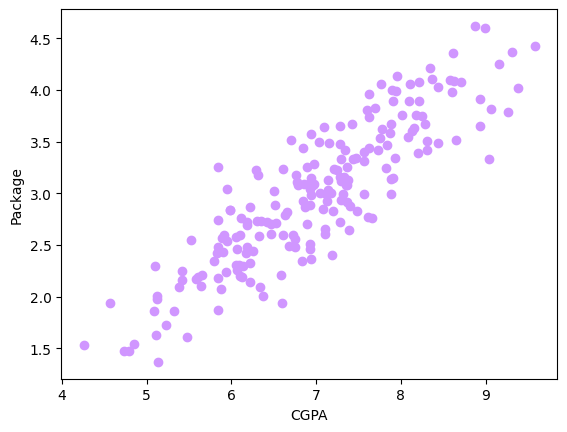

In [4]:
plot.scatter(df['cgpa'], df['package'], color="#d096ff")
plot.xlabel('CGPA')
plot.ylabel('Package')

In [5]:
x = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [6]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 40
)

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
lr = LinearRegression()

lr.fit(xtrain, ytrain)

LinearRegression()

Text(0, 0.5, 'Package')

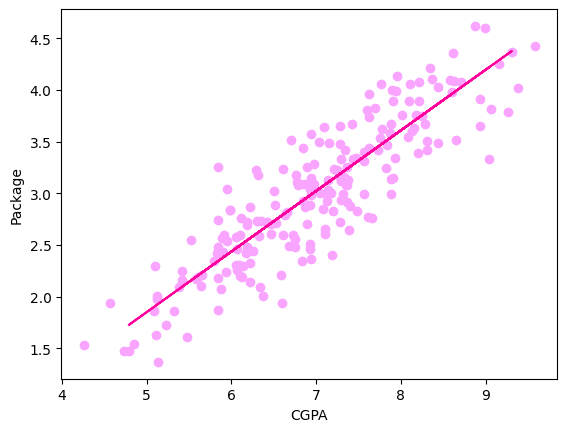

In [10]:
plot.scatter(df['cgpa'], df['package'], color="#f9a4ff")
plot.plot(xtest, lr.predict(xtest), color="#ff009d")
plot.xlabel('CGPA')
plot.ylabel('Package')

## **Regression Metrics**

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
ypred = lr.predict(xtest)

In [13]:
ytest.values

array([2.61, 2.99, 3.33, 2.87, 2.72, 2.93, 3.09, 2.83, 2.66, 3.48, 2.4 ,
       3.04, 3.64, 3.42, 2.72, 3.15, 3.76, 2.48, 2.48, 2.43, 2.76, 2.24,
       1.48, 3.08, 2.99, 3.28, 2.98, 2.82, 3.02, 2.49, 2.73, 2.26, 3.52,
       4.37, 2.6 , 3.98, 2.2 , 2.25, 2.89, 2.21])

### **Mean absolute error**

In [15]:
print("MAE :", mean_absolute_error(ytest, ypred))

MAE : 0.24999051829818955


### **Mean squared error**

In [16]:
print("MSE :", mean_squared_error(ytest, ypred))

MSE : 0.10351480752583128


### **Root mean squared error**

In [17]:
print("RMSE :", mean_squared_error(ytest, ypred) ** 0.5)

RMSE : 0.32173717150157094


### **R2 Score**

In [18]:
print("R2 Score :", r2_score(ytest, ypred))

R2 Score : 0.6462843124730799


### **Adjusted R2 Score**

In [21]:
xtest.shape

(40, 1)

In [23]:
r2 = r2_score(ytest, ypred)
rows = 40
independent_cols = 1

adjusted_r2 = 1 - (((1 - r2)*(rows - 1)) / (rows - 1 - independent_cols))

In [24]:
adjusted_r2

0.636976004906582